In [4]:
import pandas as pd

df = pd.read_csv("Student Depression Dataset.csv")

print(df.columns)

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


Chi-Square Test: Sleep Duration vs. Depression



In [6]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Sleep Duration'], df['Depression'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 276.8483796551745
p-value: 1.065310789284643e-58
Degrees of freedom: 4


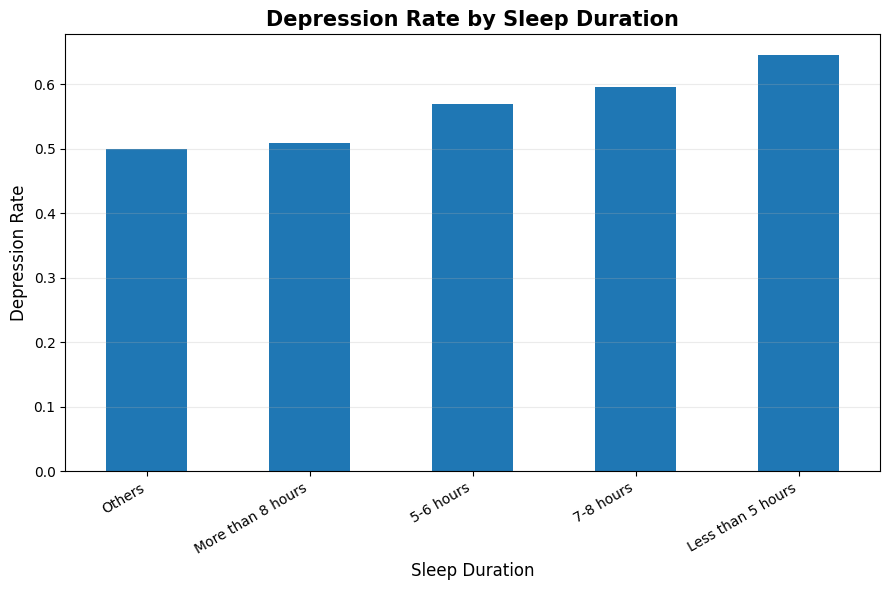

In [19]:
# Figure 1 - Sleep Duration and Depression

import matplotlib.pyplot as plt

# Calculate depression rate for each sleep duration category
sleep_depression = df.groupby('Sleep Duration')['Depression'].mean().sort_values()

plt.figure(figsize=(9,6))

sleep_depression.plot(kind='bar')

plt.title(
    'Depression Rate by Sleep Duration',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Sleep Duration', fontsize=12)
plt.ylabel('Depression Rate', fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.25)

plt.tight_layout()

# Save for Overleaf
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")

plt.show()

Interaction Preview- Depression Rate by Academic Pressure and Sleep Duration

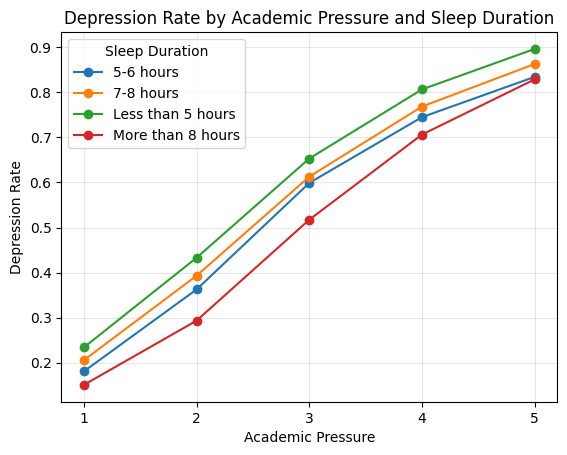

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
df_filtered = df[
    (df['Sleep Duration'] != 'Others') &
    (df['Academic Pressure'] != 0)
]

interaction = df_filtered.groupby(
    ['Academic Pressure', 'Sleep Duration']
)['Depression'].mean().reset_index()


for sleep_group in interaction['Sleep Duration'].unique():
    subset = interaction[interaction['Sleep Duration'] == sleep_group]
    plt.plot(
        subset['Academic Pressure'],
        subset['Depression'],
        marker='o',
        label=sleep_group
    )

plt.title('Depression Rate by Academic Pressure and Sleep Duration')
plt.xlabel('Academic Pressure')
plt.ylabel('Depression Rate')
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title='Sleep Duration')
plt.grid(True, alpha=0.3)

plt.savefig("figure3.png", dpi=300, bbox_inches="tight")

plt.show()

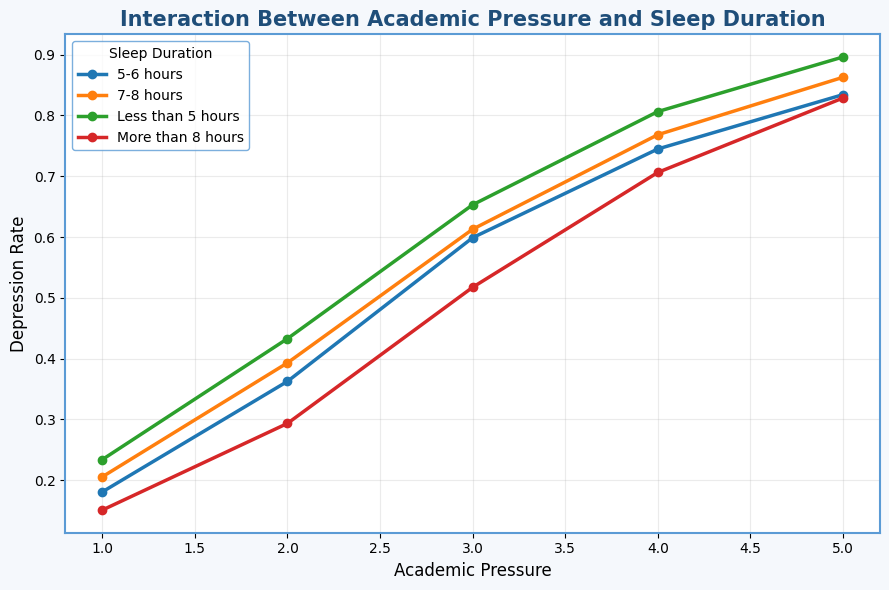

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6), facecolor='#f5f8fc')

for sleep_group in interaction['Sleep Duration'].unique():
    subset = interaction[interaction['Sleep Duration'] == sleep_group]

    plt.plot(
        subset['Academic Pressure'],
        subset['Depression'],
        marker='o',
        linewidth=2.5,
        label=sleep_group
    )

plt.title(
    'Interaction Between Academic Pressure and Sleep Duration',
    fontsize=15,
    fontweight='bold',
    color='#1f4e79'
)

plt.xlabel('Academic Pressure', fontsize=12)
plt.ylabel('Depression Rate', fontsize=12)

plt.grid(True, alpha=0.25)

ax = plt.gca()
ax.set_facecolor('#ffffff')

for spine in ax.spines.values():
    spine.set_color('#5b9bd5')
    spine.set_linewidth(1.5)

legend = plt.legend(
    title='Sleep Duration',
    frameon=True,
    fancybox=True
)

legend.get_frame().set_edgecolor('#5b9bd5')
legend.get_frame().set_facecolor('white')

plt.tight_layout()

plt.savefig("figure2.png", dpi=300, bbox_inches="tight")

plt.show()

Mann–Whitney U Test

### Mann–Whitney U Test – Hypotheses

**H₀ (Null Hypothesis):**  
The distribution of Academic Pressure is the same for students with and without depression.

**H₁ (Alternative Hypothesis):**  
The distribution of Academic Pressure differs between students with and without depression.

**Significance level:** α = 0.05

In [9]:
from scipy.stats import mannwhitneyu

depressed = df[df['Depression'] == 1]['Academic Pressure'].dropna()
not_depressed = df[df['Depression'] == 0]['Academic Pressure'].dropna()

u_stat, p_value = mannwhitneyu(
    depressed,
    not_depressed,
    alternative='two-sided'
)

print("U-statistic:", u_stat)
print("p-value:", p_value)

print("Median Academic Pressure - Depression:", depressed.median())
print("Median Academic Pressure - No Depression:", not_depressed.median())

U-statistic: 145556846.5
p-value: 0.0
Median Academic Pressure - Depression: 4.0
Median Academic Pressure - No Depression: 2.0


/tmp/ipykernel_1380/2045377089.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


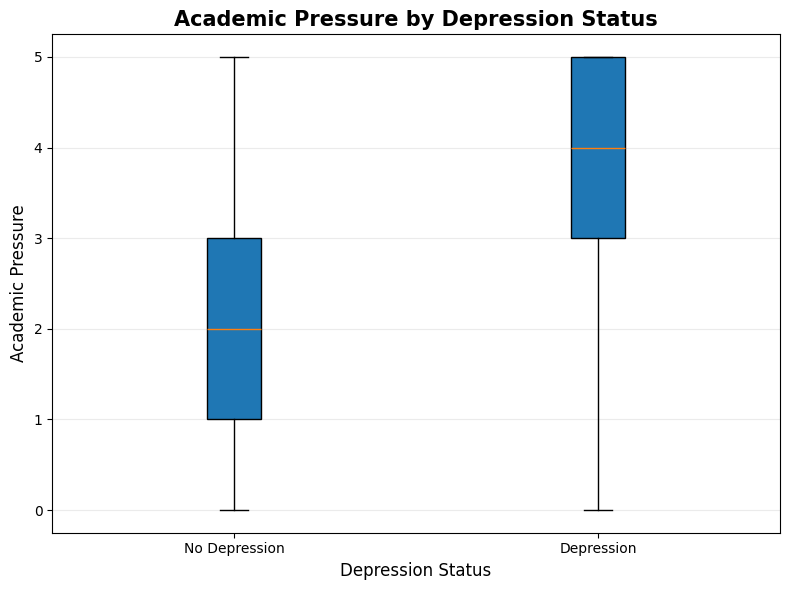

In [21]:
# Figure 3 - Academic Pressure by Depression Status

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.boxplot(
    [not_depressed, depressed],
    labels=['No Depression', 'Depression'],
    patch_artist=True
)

plt.title(
    'Academic Pressure by Depression Status',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Depression Status', fontsize=12)
plt.ylabel('Academic Pressure', fontsize=12)

plt.grid(axis='y', alpha=0.25)

plt.tight_layout()

# Save for Overleaf
plt.savefig("figure4.png", dpi=300, bbox_inches="tight")

plt.show()

# Confidence intervals for the median difference

In [10]:
import numpy as np

# Number of bootstrap samples
n_bootstrap = 1000

bootstrap_differences = []

for _ in range(n_bootstrap):
    sample_dep = np.random.choice(depressed, size=len(depressed), replace=True)
    sample_not_dep = np.random.choice(not_depressed, size=len(not_depressed), replace=True)

    diff = np.median(sample_dep) - np.median(sample_not_dep)
    bootstrap_differences.append(diff)

# 95% Confidence Interval
lower = np.percentile(bootstrap_differences, 2.5)
upper = np.percentile(bootstrap_differences, 97.5)

print(f"95% Confidence Interval for the median difference: [{lower:.2f}, {upper:.2f}]")

95% Confidence Interval for the median difference: [2.00, 2.00]


### Interpretation

The 95% confidence interval provides a plausible range for the difference in median academic pressure between students with and without depression.

If the confidence interval does not include zero, this supports the conclusion that academic pressure differs significantly between the two groups.

Logistic Regression

In [12]:
import statsmodels.formula.api as smf

# Logistic regression model with interaction
model = smf.logit(
    "Depression ~ Q('Academic Pressure') * Q('Sleep Duration')",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.553142
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:                27901
Model:                          Logit   Df Residuals:                    27891
Method:                           MLE   Df Model:                            9
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                  0.1847
Time:                        20:18:14   Log-Likelihood:                -15433.
converged:                       True   LL-Null:                       -18930.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------
In

Odds Ratios and 95% Confidence Intervals

In [14]:
import numpy as np

# Odds Ratios
odds_ratios = np.exp(model.params)

# Confidence Intervals
conf = np.exp(model.conf_int())
conf.columns = ['2.5%', '97.5%']

results = conf.copy()
results['Odds Ratio'] = odds_ratios

print(results)

                                                        2.5%      97.5%  \
Intercept                                           0.102768   0.138560   
Q('Sleep Duration')[T.7-8 hours]                    0.888038   1.332610   
Q('Sleep Duration')[T.Less than 5 hours]            0.977944   1.454379   
Q('Sleep Duration')[T.More than 8 hours]            0.553195   0.849412   
Q('Sleep Duration')[T.Others]                       0.019452  33.829741   
Q('Academic Pressure')                              2.105079   2.309826   
Q('Academic Pressure'):Q('Sleep Duration')[T.7-...  0.951420   1.080317   
Q('Academic Pressure'):Q('Sleep Duration')[T.Le...  0.987033   1.118260   
Q('Academic Pressure'):Q('Sleep Duration')[T.Mo...  0.978730   1.116687   
Q('Academic Pressure'):Q('Sleep Duration')[T.Ot...  0.303372   2.967002   

                                                    Odds Ratio  
Intercept                                             0.119329  
Q('Sleep Duration')[T.7-8 hours]            

Model Performance

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predicted probabilities
pred_prob = model.predict(df)

# Convert probabilities to predictions
pred = (pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(df["Depression"], pred)

print(f"Accuracy: {accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(df["Depression"], pred))

Accuracy: 0.728

Confusion Matrix:
[[ 6490  5075]
 [ 2504 13832]]
